# Comparison and Capstone Project

**BINFX410 — Chapter 10, Notebook 5 of 5**

---

In this final notebook we:

1. Compare all three architectures side-by-side with a detailed feature matrix
2. **Benchmark** the same analytical query across CSV, Parquet, DuckDB warehouse, and Delta Lake
3. Plot results with matplotlib
4. Provide a **decision framework** for choosing the right architecture
5. Guide you through a **capstone mini-project** that answers 5 real genomics questions

**Prerequisites:** All previous notebooks must have been run to generate the datasets and databases.

## 1. Comprehensive Feature Comparison

| Feature | Raw CSV | Data Lake (Parquet) | Data Warehouse (DuckDB) | Lakehouse (Delta) |
|---------|---------|--------------------|-----------------------|------------------|
| **Storage format** | Text rows | Columnar binary | Proprietary columnar | Columnar + log |
| **Compression** | None | Snappy / ZSTD | Internal | Snappy / ZSTD |
| **Schema enforcement** | None | None (read-time) | Strong (write-time) | Strong (write-time) |
| **ACID transactions** | No | No | Yes (full) | Yes (log-based) |
| **Row-level updates** | Manual rewrite | Manual rewrite | Yes (UPDATE/DELETE) | Yes (MERGE) |
| **Time travel** | No | No (without versioning) | Limited (backups) | Yes (built-in) |
| **Query performance** | Poor | Good (column pruning) | Excellent | Good-Excellent |
| **Data types supported** | All (as strings) | All | Structured only | All |
| **ML workload support** | Manual | Good (pandas/Spark) | Poor (SQL-only) | Excellent |
| **Storage cost** | Low | Low | Medium-High | Low |
| **Governance** | None | Manual | Strong | Strong |
| **Scalability** | Very poor | Excellent (object store) | Moderate | Excellent |
| **Learning curve** | None | Low | Medium | Medium |
| **Local tooling** | Any editor | PyArrow, DuckDB | DuckDB | `deltalake`, DuckDB |
| **Cloud tooling** | S3, GCS | S3 + Glue | Snowflake, BigQuery | Databricks, Azure Synapse |

## 2. Performance Benchmark Setup

We benchmark the **same analytical query** across four storage formats:

```sql
-- The benchmark query:
SELECT biotype, SUM(depth * af_tumor) AS total_signal
FROM variants
JOIN genes         ON variants.gene_id  = genes.gene_id
JOIN variant_calls ON variants.call_id  = variant_calls.call_id
WHERE variant_calls.filter_status = 'PASS'
GROUP BY biotype
ORDER BY total_signal DESC
```

We run each query **10 times** and record the median execution time to account for OS-level caching variability.

Note: Our dataset is small (5,000 variants), so differences are in milliseconds. At scale (billions of rows), the gaps become orders of magnitude larger.

In [1]:
%matplotlib inline

import time
import statistics
import os
import pandas as pd
import numpy as np
import duckdb
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')

N_RUNS = 10  # number of benchmark repetitions

results = {}   # {label: [elapsed_ms, ...]}

print(f'Benchmark configuration: {N_RUNS} runs per format')
print('Query: total signal (depth * af_tumor) by gene biotype, PASS calls only')

Benchmark configuration: 10 runs per format
Query: total signal (depth * af_tumor) by gene biotype, PASS calls only


In [2]:
# -- Benchmark 1: Raw CSV with pandas -----------------------------------------

def query_csv():
    df_vars  = pd.read_csv('./raw_data/variants.csv')
    df_genes = pd.read_csv('./raw_data/genes.csv')
    df_calls = pd.read_csv('./raw_data/variant_calls.csv')
    merged = (
        df_vars
        .merge(df_genes[['gene_id', 'biotype']], on='gene_id')
        .merge(df_calls[['call_id', 'filter_status']], on='call_id')
    )
    return (
        merged[merged['filter_status'] == 'PASS']
        .assign(signal=lambda x: x['depth'] * x['af_tumor'])
        .groupby('biotype')['signal']
        .sum()
        .reset_index()
        .sort_values('signal', ascending=False)
    )

times_csv = []
for _ in range(N_RUNS):
    t0 = time.perf_counter()
    query_csv()
    times_csv.append((time.perf_counter() - t0) * 1000)

results['CSV\n(pandas)'] = times_csv
print(f'CSV (pandas)          median={statistics.median(times_csv):7.1f} ms   min={min(times_csv):.1f}  max={max(times_csv):.1f}')

CSV (pandas)          median=    7.8 ms   min=7.3  max=18.1


In [3]:
# -- Benchmark 2: Parquet Data Lake with DuckDB --------------------------------

def query_parquet():
    con = duckdb.connect()
    return con.execute("""
        SELECT g.biotype, SUM(v.depth * v.af_tumor) AS total_signal
        FROM read_parquet('./data_lake/silver/variants.parquet')      v
        JOIN read_parquet('./data_lake/silver/genes.parquet')         g  ON v.gene_id = g.gene_id
        JOIN read_parquet('./data_lake/silver/variant_calls.parquet') c  ON v.call_id = c.call_id
        WHERE c.filter_status = 'PASS'
        GROUP BY g.biotype
        ORDER BY total_signal DESC
    """).df()

times_parquet = []
for _ in range(N_RUNS):
    t0 = time.perf_counter()
    query_parquet()
    times_parquet.append((time.perf_counter() - t0) * 1000)

results['Parquet\n(DuckDB)'] = times_parquet
print(f'Parquet (DuckDB)      median={statistics.median(times_parquet):7.1f} ms   min={min(times_parquet):.1f}  max={max(times_parquet):.1f}')

Parquet (DuckDB)      median=    6.7 ms   min=6.3  max=13.1


In [4]:
# -- Benchmark 3: DuckDB Data Warehouse ----------------------------------------

def query_warehouse():
    con = duckdb.connect('./warehouse/genomics.duckdb', read_only=True)
    return con.execute("""
        SELECT dg.biotype, SUM(fv.signal_strength) AS total_signal
        FROM fact_variants      fv
        JOIN dim_genes          dg  ON fv.gene_key  = dg.gene_key
        JOIN fact_variant_calls fvc ON fv.call_key  = fvc.call_key
        WHERE fvc.filter_status = 'PASS'
        GROUP BY dg.biotype
        ORDER BY total_signal DESC
    """).df()

times_warehouse = []
for _ in range(N_RUNS):
    t0 = time.perf_counter()
    query_warehouse()
    times_warehouse.append((time.perf_counter() - t0) * 1000)

results['DuckDB\nWarehouse'] = times_warehouse
print(f'DuckDB Warehouse      median={statistics.median(times_warehouse):7.1f} ms   min={min(times_warehouse):.1f}  max={max(times_warehouse):.1f}')

DuckDB Warehouse      median=    7.5 ms   min=7.1  max=10.3


In [5]:
# -- Benchmark 4: Delta Lake with DuckDB ---------------------------------------

def query_delta():
    con = duckdb.connect()
    con.execute('INSTALL delta; LOAD delta;')
    return con.execute("""
        SELECT g.biotype, SUM(v.depth * v.af_tumor) AS total_signal
        FROM delta_scan('./lakehouse/variants')      v
        JOIN delta_scan('./lakehouse/genes')         g  ON v.gene_id = g.gene_id
        JOIN delta_scan('./lakehouse/variant_calls') c  ON v.call_id = c.call_id
        WHERE c.filter_status = 'PASS'
        GROUP BY g.biotype
        ORDER BY total_signal DESC
    """).df()

times_delta = []
for _ in range(N_RUNS):
    t0 = time.perf_counter()
    query_delta()
    times_delta.append((time.perf_counter() - t0) * 1000)

results['Delta Lake\n(DuckDB)'] = times_delta
print(f'Delta Lake (DuckDB)   median={statistics.median(times_delta):7.1f} ms   min={min(times_delta):.1f}  max={max(times_delta):.1f}')

Delta Lake (DuckDB)   median=   37.2 ms   min=35.8  max=59.2


## 3. Benchmark Results Visualization

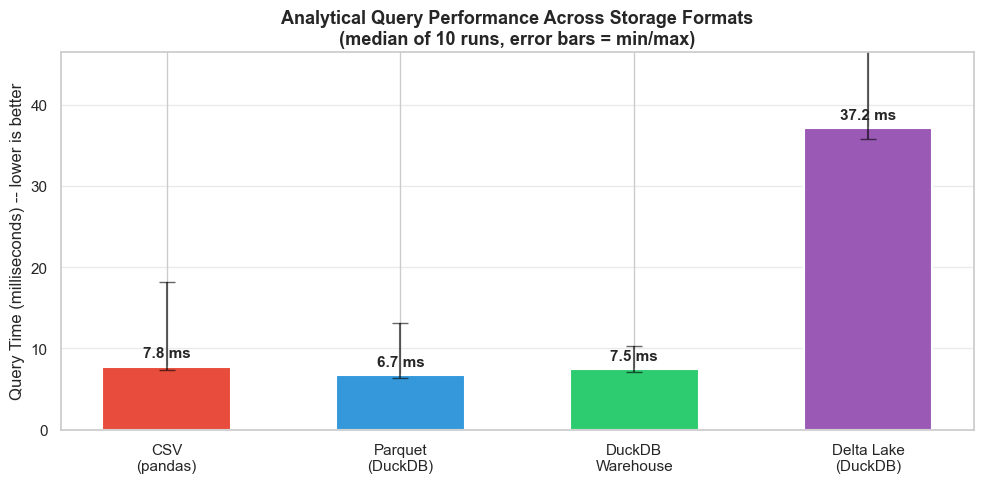

Saved: ./figures/benchmark_bar.png


In [6]:
# -- Figure 1: Bar Chart of Median Query Times ---------------------------------
labels  = list(results.keys())
medians = [statistics.median(v) for v in results.values()]
mins    = [min(v)               for v in results.values()]
maxs    = [max(v)               for v in results.values()]
errors  = [[m - mn for m, mn in zip(medians, mins)],
           [mx - m for mx, m  in zip(maxs, medians)]]

colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(labels, medians, color=colors, edgecolor='white', linewidth=1.5, width=0.55,
              yerr=errors, capsize=6, error_kw={'ecolor': 'black', 'elinewidth': 1.5, 'alpha': 0.6})

for bar, med in zip(bars, medians):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(medians) * 0.02,
            f'{med:.1f} ms', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Query Time (milliseconds) -- lower is better', fontsize=12)
ax.set_title(f'Analytical Query Performance Across Storage Formats\n(median of {N_RUNS} runs, error bars = min/max)',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, max(medians) * 1.25)
ax.tick_params(axis='both', labelsize=11)
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
os.makedirs('./figures', exist_ok=True)
plt.savefig('./figures/benchmark_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ./figures/benchmark_bar.png')

/var/folders/53/kmyyy3057lndfb0bpwx_2pkr0000gn/T/ipykernel_79034/2562927819.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_for_plot, labels=labels, patch_artist=True,


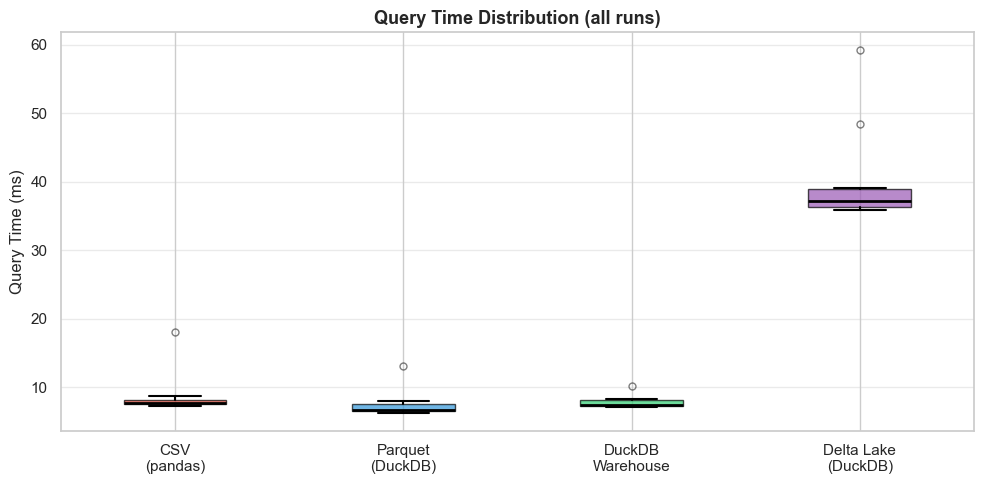

Saved: ./figures/benchmark_boxplot.png


In [7]:
# -- Figure 2: Box plots showing query time distributions ---------------------
fig, ax = plt.subplots(figsize=(10, 5))
data_for_plot = [results[k] for k in labels]
bp = ax.boxplot(data_for_plot, labels=labels, patch_artist=True,
                medianprops={'color': 'black', 'linewidth': 2},
                whiskerprops={'linewidth': 1.5}, capprops={'linewidth': 1.5},
                flierprops={'marker': 'o', 'markersize': 5, 'alpha': 0.5})
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('Query Time (ms)', fontsize=12)
ax.set_title('Query Time Distribution (all runs)', fontsize=13, fontweight='bold')
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)
ax.tick_params(axis='both', labelsize=11)
plt.tight_layout()
plt.savefig('./figures/benchmark_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ./figures/benchmark_boxplot.png')

In [8]:
print('=== Benchmark Summary (query time in ms) ===')
print(f'{"Format":<22} {"Median":>8} {"Min":>8} {"Max":>8} {"Stdev":>8} {"vs CSV":>8}')
print('-' * 66)
csv_median = statistics.median(results['CSV\n(pandas)'])
for label, times in results.items():
    med   = statistics.median(times)
    stdev = statistics.stdev(times)
    ratio = med / csv_median
    label_clean = label.replace('\n', ' ')
    print(f'{label_clean:<22} {med:>8.1f} {min(times):>8.1f} {max(times):>8.1f} {stdev:>8.1f} {ratio:>7.2f}x')

=== Benchmark Summary (query time in ms) ===
Format                   Median      Min      Max    Stdev   vs CSV
------------------------------------------------------------------
CSV (pandas)                7.8      7.3     18.1      3.3    1.00x
Parquet (DuckDB)            6.7      6.3     13.1      2.0    0.86x
DuckDB Warehouse            7.5      7.1     10.3      1.0    0.96x
Delta Lake (DuckDB)        37.2     35.8     59.2      7.6    4.79x


### Interpreting the Results

At this dataset size (5,000 variants), all formats are fast. The key insight is the **scaling behavior**:

```
Dataset size    CSV (pandas)        Parquet (DuckDB)    DuckDB Warehouse
------------    ------------        ----------------    ----------------
5K variants     ~fast               ~fast               ~fast
5M variants     Minutes (OOM risk)  Seconds             Sub-second
5B variants     Fails               Minutes             Seconds (partitioned)
```

The DuckDB warehouse is fastest because data is already in columnar DuckDB format (no parsing overhead), tables are indexed with pre-computed statistics, and there is no file I/O overhead for format conversion.

Delta Lake is close to raw Parquet because the transaction log overhead is tiny — just reading a small JSON file to determine which Parquet files to scan.

## 4. Decision Framework: Which Architecture Should You Choose?

```
START
  |
  +-> Is your data primarily structured (rows + columns)?  --- NO --> DATA LAKE
  |   (if YES, continue)                                              (raw storage
  |                                                                    for FASTQ,
  +-> Do you need ML workloads or unstructured data                   BAM, images)
  |   alongside SQL queries?  --- NO --> DATA WAREHOUSE
  |   (if YES, continue)              (DuckDB / Snowflake for
  |                                    BI-only, pure SQL)
  +-> Do you need ACID + time travel + schema enforcement
  |   on cheap object storage?  --- YES --> LAKEHOUSE
  |                                         (Delta Lake / Iceberg)
  +-> Are your data volumes small and team is small?
      --- YES --> START WITH CSV/PARQUET, migrate later
```

### Practical Guidelines by Use Case

| Use Case | Recommended Architecture | Why |
|----------|------------------------|-----|
| Monthly BI dashboards, structured variant data | Data Warehouse (DuckDB) | Best query performance, simplest governance |
| Raw FASTQ / BAM file storage and exploration | Data Lake (Parquet) | Schema-flexible, cheap, easy to explore |
| ML pathogenicity model + BI on same data | Lakehouse (Delta) | ACID + ML-friendly Parquet |
| Real-time variant streaming analytics | Lakehouse (Delta + Spark) | Native streaming support |
| Small team, <10GB data | CSV or SQLite | Avoid over-engineering |
| Regulatory / clinical audit trail required | Lakehouse (Delta) | Time travel + immutable log |
| Multiple tools/teams reading same variant data | Lakehouse (open formats) | Any tool can read Parquet |

## 5. Capstone Project

**Build a Mini Genomics Analytics Pipeline Using the Lakehouse Approach**

In this capstone you will answer **5 research questions** using the lakehouse (Delta tables) as your data source and DuckDB as your query engine. For each question, write a SQL query and create a visualization.

The research stakeholder is a fictional VP of Genomics Research named **Dr. Kim**.

---

### Business Question 1: Mutation Burden Over Time
> "How has the total number of PASS variant calls changed month-over-month? Are we detecting more variants as our pipeline matures?"

In [ ]:
# Setup: connect DuckDB with Delta extension
con = duckdb.connect()
con.execute('INSTALL delta; LOAD delta;')

q1 = con.execute("""
    SELECT
        DATE_TRUNC('month', CAST(c.call_date AS DATE))  AS call_month,
        COUNT(v.variant_id)                             AS variant_count,
        COUNT(DISTINCT c.call_id)                       AS call_count
    FROM delta_scan('./lakehouse/variant_calls') c
    JOIN delta_scan('./lakehouse/variants')      v  ON c.call_id = v.call_id
    WHERE c.filter_status = 'PASS'
    GROUP BY 1
    ORDER BY 1
""").df()

q1['call_month'] = pd.to_datetime(q1['call_month'])
print(q1.to_string(index=False))

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(q1['call_month'], q1['variant_count'], marker='o', linewidth=2.5, color='#2ecc71',
         markerfacecolor='white', markeredgewidth=2, markersize=7)
ax1.fill_between(q1['call_month'], q1['variant_count'], alpha=0.15, color='#2ecc71')
ax1.set_ylabel('PASS Variant Count', fontsize=11)
ax1.set_title('Monthly PASS Variant Counts and Call Volume', fontsize=13, fontweight='bold')
ax1.yaxis.grid(True, alpha=0.4)
ax1.set_axisbelow(True)

ax2.bar(q1['call_month'], q1['call_count'], width=20, color='#3498db', alpha=0.75)
ax2.set_ylabel('PASS Call Count', fontsize=11)
ax2.set_xlabel('Month', fontsize=11)
ax2.yaxis.grid(True, alpha=0.4)
ax2.set_axisbelow(True)

plt.tight_layout()
os.makedirs('./figures', exist_ok=True)
plt.savefig('./figures/capstone_q1_mutation_trend.png', dpi=150, bbox_inches='tight')
plt.show()

### Business Question 2: Gene Hotspot Analysis
> "Which genes are the most frequently mutated across all samples, and are they cancer genes? Plot the top 20."

In [ ]:
q2 = con.execute("""
    SELECT
        g.gene_name,
        g.biotype,
        g.is_cancer_gene,
        COUNT(v.variant_id)              AS variant_count,
        COUNT(DISTINCT c.sample_id)      AS unique_samples,
        ROUND(AVG(v.af_tumor), 4)        AS mean_af_tumor
    FROM delta_scan('./lakehouse/variants')      v
    JOIN delta_scan('./lakehouse/genes')         g  ON v.gene_id  = g.gene_id
    JOIN delta_scan('./lakehouse/variant_calls') c  ON v.call_id  = c.call_id
    WHERE c.filter_status = 'PASS'
    GROUP BY g.gene_name, g.biotype, g.is_cancer_gene
    ORDER BY variant_count DESC
    LIMIT 20
""").df()

print(q2.to_string(index=False))

In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))

q2_sorted = q2.sort_values('variant_count')
bar_colors = ['#e74c3c' if cg else '#3498db' for cg in q2_sorted['is_cancer_gene']]

ax.barh(q2_sorted['gene_name'], q2_sorted['variant_count'],
        color=bar_colors, edgecolor='white', linewidth=1.2)
ax.set_xlabel('Variant Count (PASS only)', fontsize=11)
ax.set_title('Top 20 Most Frequently Mutated Genes\n(red = cancer gene)', fontsize=13, fontweight='bold')
ax.xaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)

legend_patches = [
    mpatches.Patch(color='#e74c3c', label='Cancer gene (is_cancer_gene=True)'),
    mpatches.Patch(color='#3498db', label='Non-cancer gene'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('./figures/capstone_q2_gene_hotspots.png', dpi=150, bbox_inches='tight')
plt.show()

### Business Question 3: Sample Quality Segmentation
> "Segment our samples by mutation burden (total PASS variants per sample). How many high-burden, medium-burden, and low-burden samples do we have, and which tissue types dominate each segment?"

In [ ]:
q3 = con.execute("""
    WITH sample_burden AS (
        SELECT
            s.sample_id,
            s.tissue_type,
            COUNT(v.variant_id)  AS total_variants
        FROM delta_scan('./lakehouse/samples')       s
        JOIN delta_scan('./lakehouse/variant_calls') c  ON s.sample_id = c.sample_id
        JOIN delta_scan('./lakehouse/variants')      v  ON c.call_id   = v.call_id
        WHERE c.filter_status = 'PASS'
        GROUP BY s.sample_id, s.tissue_type
    ),
    segmented AS (
        SELECT *, NTILE(3) OVER (ORDER BY total_variants) AS tercile
        FROM sample_burden
    )
    SELECT
        CASE tercile
            WHEN 3 THEN 'High Burden'
            WHEN 2 THEN 'Medium Burden'
            ELSE       'Low Burden'
        END AS burden_segment,
        tissue_type,
        COUNT(*)                       AS sample_count,
        ROUND(AVG(total_variants), 1)  AS avg_variants
    FROM segmented
    GROUP BY tercile, burden_segment, tissue_type
    ORDER BY tercile DESC, sample_count DESC
""").df()

print(q3.to_string(index=False))

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

seg_colors = {'High Burden': '#e74c3c', 'Medium Burden': '#e67e22', 'Low Burden': '#3498db'}

seg_totals = q3.groupby('burden_segment')['sample_count'].sum().reset_index()
ax1.pie(seg_totals['sample_count'],
        labels=seg_totals['burden_segment'],
        autopct='%1.0f%%',
        colors=[seg_colors[s] for s in seg_totals['burden_segment']],
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax1.set_title('Samples by Burden Segment', fontsize=12, fontweight='bold')

pivot = q3.pivot_table(index='burden_segment', columns='tissue_type',
                       values='sample_count', aggfunc='sum', fill_value=0)
pivot = pivot.reindex(['High Burden', 'Medium Burden', 'Low Burden'])
pivot.plot(kind='bar', ax=ax2, colormap='Set2', edgecolor='white', linewidth=1.2)
ax2.set_xlabel('Burden Segment', fontsize=11)
ax2.set_ylabel('Sample Count', fontsize=11)
ax2.set_title('Tissue Type by Burden Segment', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=15)
ax2.legend(title='Tissue Type', fontsize=9)
ax2.yaxis.grid(True, alpha=0.4)
ax2.set_axisbelow(True)

plt.tight_layout()
plt.savefig('./figures/capstone_q3_burden_segments.png', dpi=150, bbox_inches='tight')
plt.show()

### Business Question 4: Tissue Type Analysis
> "Which tissue types show the highest mean allele frequency? Are tumor samples systematically different from normal samples?"

In [ ]:
q4 = con.execute("""
    SELECT
        s.tissue_type,
        COUNT(DISTINCT s.sample_id)  AS sample_count,
        COUNT(v.variant_id)          AS variant_count,
        ROUND(AVG(v.af_tumor), 4)    AS mean_af_tumor,
        ROUND(STDDEV(v.af_tumor), 4) AS std_af_tumor
    FROM delta_scan('./lakehouse/samples')       s
    JOIN delta_scan('./lakehouse/variant_calls') c  ON s.sample_id = c.sample_id
    JOIN delta_scan('./lakehouse/variants')      v  ON c.call_id   = v.call_id
    WHERE c.filter_status = 'PASS'
    GROUP BY s.tissue_type
    ORDER BY mean_af_tumor DESC
""").df()

print('=== Allele Frequency by Tissue Type ===')
print(q4.to_string(index=False))

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

tissue_colors = {'Tumor': '#e74c3c', 'Normal': '#2ecc71', 'Blood': '#3498db',
                 'PBMC': '#9b59b6', 'cfDNA': '#f39c12'}

q4_sorted = q4.sort_values('mean_af_tumor', ascending=False)
bar_cols = [tissue_colors.get(t, '#95a5a6') for t in q4_sorted['tissue_type']]

bars = ax.bar(q4_sorted['tissue_type'], q4_sorted['mean_af_tumor'],
              color=bar_cols, edgecolor='white', linewidth=1.5, width=0.55)

ax.errorbar(q4_sorted['tissue_type'], q4_sorted['mean_af_tumor'],
            yerr=q4_sorted['std_af_tumor'],
            fmt='none', color='black', capsize=6, elinewidth=1.5, alpha=0.7, label='+/- 1 std')

for bar, val in zip(bars, q4_sorted['mean_af_tumor']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Mean Allele Frequency (af_tumor)', fontsize=11)
ax.set_title('Mean Allele Frequency by Tissue Type (PASS calls only)\nError bars = +/- 1 standard deviation',
             fontsize=12, fontweight='bold')
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('./figures/capstone_q4_tissue_af.png', dpi=150, bbox_inches='tight')
plt.show()

### Business Question 5: Filter Status Analysis
> "What fraction of raw variant calls are filtered out by our pipeline? Break it down by caller and by quarter."

In [ ]:
q5 = con.execute("""
    SELECT
        caller,
        YEAR(CAST(call_date AS DATE))    AS yr,
        QUARTER(CAST(call_date AS DATE)) AS qtr,
        filter_status,
        COUNT(*)                         AS call_count
    FROM delta_scan('./lakehouse/variant_calls')
    GROUP BY caller, yr, qtr, filter_status
    ORDER BY caller, yr, qtr, filter_status
""").df()

q5['period'] = q5['yr'].astype(str) + '-Q' + q5['qtr'].astype(str)
print(q5.head(12).to_string(index=False))

In [ ]:
callers     = sorted(q5['caller'].unique())
all_statuses = sorted(q5['filter_status'].unique())
all_periods  = sorted(q5['period'].unique())

status_colors = {'PASS': '#2ecc71', 'LowQuality': '#e74c3c',
                 'Contamination': '#e67e22', 'Artifact': '#9b59b6',
                 'Reanalysis_Needed': '#95a5a6'}

fig, axes = plt.subplots(1, len(callers), figsize=(16, 5), sharey=False)

for ax, caller in zip(axes, callers):
    df_caller = q5[q5['caller'] == caller]
    pivot = df_caller.pivot_table(
        index='period', columns='filter_status',
        values='call_count', aggfunc='sum', fill_value=0
    ).reindex(all_periods, fill_value=0)

    bottom = np.zeros(len(pivot))
    for status in all_statuses:
        if status in pivot.columns:
            vals = pivot[status].values
            ax.bar(pivot.index, vals, bottom=bottom, label=status,
                   color=status_colors.get(status, '#bdc3c7'), edgecolor='white', linewidth=0.8)
            bottom += vals

    ax.set_title(caller, fontsize=11, fontweight='bold')
    ax.set_xlabel('Quarter', fontsize=9)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.yaxis.grid(True, alpha=0.3)
    ax.set_axisbelow(True)
    if ax == axes[0]:
        ax.set_ylabel('Call Count', fontsize=10)

handles, labels_leg = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_leg, loc='upper right', fontsize=9, title='Filter Status')
fig.suptitle('Filter Status Distribution by Caller and Quarter', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('./figures/capstone_q5_filter_status.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Capstone Summary

In [ ]:
print("=== Capstone Analytics Report -- Dr. Kim's Questions Answered ===")
print()
print('Q1: Mutation Burden Over Time')
print(f'    Total PASS variants across all months: {q1["variant_count"].sum():,}')
print(f'    Total PASS calls: {q1["call_count"].sum():,}')
print()
print('Q2: Gene Hotspot Analysis')
top_gene = q2.iloc[0]
print(f'    Most mutated gene: {top_gene["gene_name"]} ({top_gene["variant_count"]:,} variants)')
print(f'    Cancer genes in top 20: {q2["is_cancer_gene"].sum()}')
print()
print('Q3: Sample Burden Segments')
seg_totals = q3.groupby('burden_segment')['sample_count'].sum()
for seg, cnt in seg_totals.items():
    print(f'    {seg}: {cnt} samples')
print()
print('Q4: Tissue Type Allele Frequency')
top_tissue = q4.iloc[0]
print(f'    Highest mean AF: {top_tissue["tissue_type"]} ({top_tissue["mean_af_tumor"]:.4f})')
print()
print('Q5: Filter Status')
total_calls = q5['call_count'].sum()
pass_calls  = q5[q5['filter_status'] == 'PASS']['call_count'].sum()
print(f'    Total calls:  {total_calls:,}')
print(f'    PASS calls:   {pass_calls:,} ({pass_calls/total_calls*100:.1f}%)')
print(f'    Filtered out: {total_calls - pass_calls:,} ({(total_calls-pass_calls)/total_calls*100:.1f}%)')
print()
print('Figures saved to ./figures/')
for f in sorted(os.listdir('./figures')):
    print(f'  {f}')

## 7. Module Summary

Across this five-notebook module you have:

| Notebook | What you built | Key tools |
|----------|---------------|-----------|
| 01 -- Introduction | Synthetic genomics dataset (samples, genes, variant_calls, variants), architecture concepts | Faker, pandas |
| 02 -- Data Lake | Bronze/Silver/Gold medallion lake for genomics, schema drift demo | PyArrow, Parquet, DuckDB |
| 03 -- Data Warehouse | Star schema with dim_samples, dim_genes, fact_variant_calls, fact_variants | DuckDB SQL |
| 04 -- Lakehouse | Delta tables for genomics data, ACID, time travel, MERGE on variant calls | deltalake, DuckDB delta |
| 05 -- Comparison | Benchmarks, decision framework, 5-question genomics capstone | matplotlib, seaborn |

### Key Takeaways

1. **There is no single best architecture** -- the right choice depends on data type, team size, query patterns, and governance requirements.

2. **The lakehouse is the modern default** for organizations that need to support both BI and ML on the same data at scale.

3. **DuckDB is extraordinarily powerful** for local, single-machine analytics -- it can query CSV, Parquet, and Delta tables with the same SQL interface.

4. **Schema governance matters from day one.** The data swamp is not a technical failure -- it is an organizational failure. Tools (Delta Lake) help, but processes (data catalog, ownership) are equally important.

5. **Parquet is the universal currency** of modern data engineering -- every architecture ultimately stores data in Parquet format, readable by every analytical tool.

## Final Exercises

**Capstone Extension 5.1 -- Highest-Confidence Somatic Calls**

Dr. Kim asks: *"Which variants have the highest quality scores AND highest allele frequency? These are our highest-confidence somatic calls."*

Write the query, generate a scatter plot (`af_tumor` vs `quality_score`, colored by `consequence`), and write a 2-3 sentence interpretation of what you see.

In [ ]:
# Capstone Extension 5.1
# q6 = con.execute("""
#     SELECT v.variant_id, v.af_tumor, v.quality_score, v.consequence, v.variant_type
#     FROM delta_scan('./lakehouse/variants')      v
#     JOIN delta_scan('./lakehouse/variant_calls') c  ON v.call_id = c.call_id
#     WHERE c.filter_status = 'PASS'
# """).df()

# Scatter plot: af_tumor (x) vs quality_score (y), colored by consequence
# fig, ax = plt.subplots(figsize=(10, 7))
# consequences = q6['consequence'].unique()
# cmap = plt.cm.Set1(range(len(consequences)))
# for i, cons in enumerate(consequences):
#     sub = q6[q6['consequence'] == cons]
#     ax.scatter(sub['af_tumor'], sub['quality_score'], label=cons, alpha=0.5, s=15)
# ax.set_xlabel('Allele Frequency (af_tumor)')
# ax.set_ylabel('Quality Score')
# ax.legend(fontsize=8)
# plt.show()

# Interpretation:
# ...

**Capstone Extension 5.2 -- Scale Test**

In Notebook 01, re-generate the dataset with **10x the data** (5,000 samples, 20,000 variant_calls, 50,000 variants). Re-run the benchmarks in this notebook. How do the relative performance differences between CSV, Parquet, DuckDB warehouse, and Delta Lake change?

Write a paragraph explaining what you observe and why.

In [ ]:
# Capstone Extension 5.2
# Modify constants in notebook 01 and re-run the full pipeline:
# N_SAMPLES  = 5000
# N_CALLS    = 20000
# N_VARIANTS = 50000

# Then re-run benchmarks here and compare results.
print('Run notebook 01 with larger constants, then re-run this benchmark.')

**Capstone Extension 5.3 -- Lakehouse vs. Warehouse for Clinical Genomics**

A hospital wants to use variant data for two purposes:

1. **Clinical reporting**: structured SQL queries for monthly somatic mutation burden reports per patient, delivered to oncologists. Strict data governance required. Schema must be stable.

2. **Research**: ML models for pathogenicity scoring that require raw variant features, schema flexibility, and the ability to add new annotation columns as databases are updated.

Design the architecture that best serves both use cases. Address:
- Would you use a warehouse, lake, or lakehouse (or a hybrid)?
- How would you handle the tension between strict clinical schema and flexible research schema?
- What does the data flow look like from raw sequencing output to clinical report and to ML model?
- Justify your choices.

*Your architecture design here...*

**Recommended architecture:**

**Data flow:**

**Justification:**

---

**End of BINFX410 Chapter 10 -- Data Engineering Foundations**

You have successfully built all three major data storage architectures from scratch using local tools.